In [1]:
%pip install seaborn
%pip install plotly
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: seaborn in c:\users\hpvic\appdata\local\programs\python\python310\lib\site-packages (0.13.2)



You should consider upgrading via the 'c:\Users\hpvic\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hpvic\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hpvic\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
df = pd.read_csv(r"customer_data.csv")
df.head()


,customer_id,gender,age,service_type,tenure,churn
0,1,Female,22,VIP,3,1
1,2,Male,48,Premium,34,1
2,3,Male,50,VIP,59,0
3,4,Male,35,Basic,50,0
4,5,Male,42,Basic,52,0


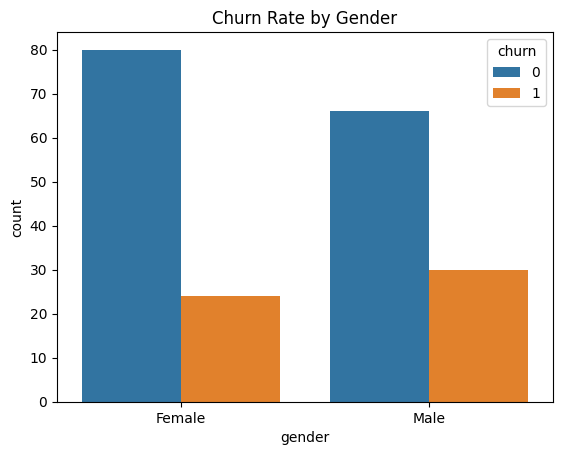


Churn rate by gender:
gender
Female    0.230769
Male      0.312500
Name: churn, dtype: float64


In [4]:
sns.countplot(data=df, x='gender', hue='churn')
plt.title('Churn Rate by Gender')
plt.show()

gender_churn = df.groupby('gender')['churn'].mean()
print("\nChurn rate by gender:")
print(gender_churn)


In [ ]:
import plotly.io as pio
# Use 'iframe' for JupyterLite for the nbformat check
pio.renderers.default = 'iframe'


In [6]:
import plotly.io as pio
import plotly.express as px

# Fix for the nbformat error
pio.renderers.default = "notebook_connected"

fig = px.histogram(
    df,
    x='age',
    color='churn',
    nbins=20,
    histnorm='percent',
    title='Churn Rate by Age Group'
)
fig.update_layout(xaxis_title='Age', yaxis_title='% of Customers')
fig.show()


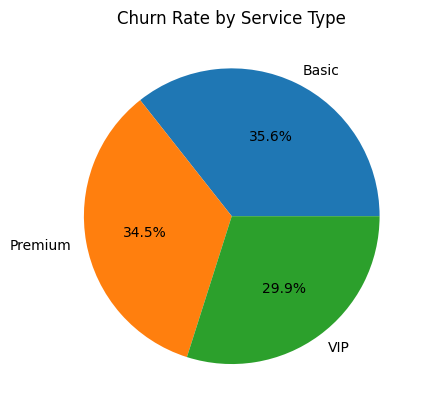

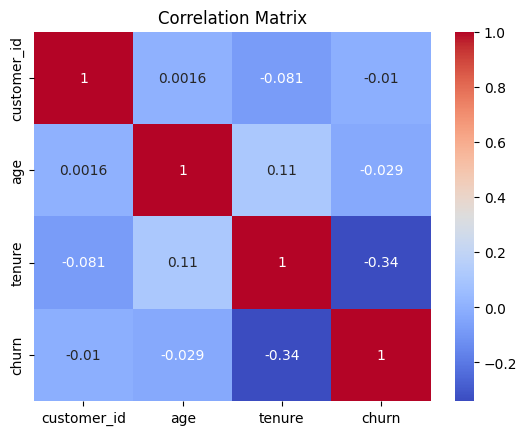

In [7]:
service_churn = df.groupby('service_type')['churn'].mean()
plt.pie(service_churn, labels=service_churn.index, autopct='%1.1f%%')
plt.title('Churn Rate by Service Type')
plt.show()

correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [9]:
fig = px.scatter(df, x='tenure', y='churn', color='churn', title='Customer Tenure vs Churn')
fig.show()

print("\nKey Insights from Data Visualization...")
print(f"1. Gender: Churn is {df.groupby('gender')['churn'].mean().to_dict()}")
print(f"2. Service: Highest churn in {df.groupby('service_type')['churn'].mean().idxmax()}")
print(f"3. Tenure: Lower tenure correlates strongly with higher churn.")
print(f"4. Top Factors: {df.corr(numeric_only=True)['churn'].sort_values(ascending=False).index[1:4].tolist()}")



Key Insights from Data Visualization...
1. Gender: Churn is {'Female': 0.23076923076923078, 'Male': 0.3125}
2. Service: Highest churn in Basic
3. Tenure: Lower tenure correlates strongly with higher churn.
4. Top Factors: ['customer_id', 'age', 'tenure']
